In [1]:
import os, pathlib, datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import yfinance as yf
from pathlib import Path
import sys
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from scipy.stats import skew, kurtosis

sns.set(context='talk', style='whitegrid')
ROOT = Path.cwd().parent

## Stage 4, 5 and 6: Data Acquisition, Storage and Preprocessing

In [2]:
CHECKS = [
    (".env", "NEEDED", "YOU create this: copy .env.example to .env. Missing = no error, but the config demo silently shows nothing"),
    (".env.example", "NEEDED", "shipped with this stage - the template you copy to .env"),
    ("src/cleaning.py", "NEEDED", "YOU write this in the homework - the import fails until you do"),
    ("src/eda.py", "NEEDED", "YOU write this in the homework - the import fails until you do"),
]

print(f"Looking in: {ROOT}\n")
missing = 0
for rel, kind, note in CHECKS:
    here = (ROOT/ rel).exists()
    if not here and kind == "NEEDED":
        missing += 1
    print(f"  [{'OK ' if here else 'MISS'}]  {kind:<8}  {rel:<34}  {note}")

if missing:
    print(f"\n{missing} needed file(s) missing. Put them at the paths above, relative to:\n  {ROOT}")
    print("If that folder looks wrong, you are running the notebook from the wrong place.")
else:
    print("\nAll needed files present.")

Looking in: c:\Users\ASUS\Desktop\project

  [OK ]  NEEDED    .env                                YOU create this: copy .env.example to .env. Missing = no error, but the config demo silently shows nothing
  [OK ]  NEEDED    .env.example                        shipped with this stage - the template you copy to .env
  [OK ]  NEEDED    src/cleaning.py                     YOU write this in the homework - the import fails until you do
  [OK ]  NEEDED    src/eda.py                          YOU write this in the homework - the import fails until you do

All needed files present.


In [3]:
load_dotenv(ROOT / ".env")

RAW = pathlib.Path(os.getenv('DATA_DIR_RAW', '../data/raw'))
PROC = pathlib.Path(os.getenv('DATA_DIR_PROCESSED', '../data/processed'))
RAW.mkdir(parents=True, exist_ok=True)
PROC.mkdir(parents=True, exist_ok=True)

print('RAW ->', RAW.resolve())
print('PROC ->', PROC.resolve())

RAW -> C:\Users\ASUS\Desktop\project\data\raw
PROC -> C:\Users\ASUS\Desktop\project\data\processed


### Helpers

In [4]:
def ts():
    return dt.datetime.now().strftime('%Y%m%d')

def save_csv(df: pd.DataFrame, prefix: str, **meta):
    mid = '_'.join([f"{k}-{v}" for k,v in meta.items()])
    path = RAW / f"{prefix}_{mid}_{ts()}.csv"
    df.to_csv(path, index=False, encoding='utf-8-sig')
    print('Saved', path)
    return path

def load_latest_data(prefix: str, symbol: str, source: str = 'yfinance') -> pd.DataFrame:
    date_str = ts()
    pattern = f"{prefix}_{source}_{symbol}_{date_str}"
    csv_files = list(RAW.glob(f"{pattern}*.csv"))
    if csv_files:
        latest_file = max(csv_files, key=lambda f: f.stat().st_mtime)
        print(f"Loading latest file: {latest_file.name}")
        return pd.read_csv(latest_file, parse_dates=['date'])
    return None

def validate(df: pd.DataFrame, required):
    missing = [c for c in required if c not in df.columns]
    price_above_0 = (df[df.columns[-1]] > 0).all() if len(df.columns) > 0 else False
    return {
        'missing': missing, 
        'shape': df.shape, 
        'na_total': int(df.isna().sum().sum()), 
        'price_above_0': price_above_0
    }

def validate_loaded(original, reloaded):
    checks = {
        'shape_equal': original.shape == reloaded.shape,
        'date_is_datetime': pd.api.types.is_datetime64_any_dtype(reloaded['date']) if 'date' in reloaded.columns else False,
        'price_is_numeric': pd.api.types.is_numeric_dtype(reloaded['close']) if 'close' in reloaded.columns else False,
    }
    return checks

### API Pull


In [5]:
SYMBOL = 'AAPL'
df_api = load_latest_data(prefix='api', symbol=SYMBOL, source='yfinance')

if df_api is not None:
    print(f"Successfully loaded existing data, total {len(df_api)} records")
else:
    print(f"Failed to load existing data, fetching new data for {SYMBOL} from yfinance...")
    df_api = yf.download(SYMBOL, period='12mo', interval='1d').reset_index()[['Date', 'Close', 'High', 'Low', 'Open', 'Volume']]
    df_api.columns = ['date', 'close', 'high', 'low','open','volume']
v_api = validate(df_api, ['date','close','high','low','open','volume']); v_api

Failed to load existing data, fetching new data for AAPL from yfinance...


[*********************100%***********************]  1 of 1 completed


{'missing': [], 'shape': (251, 6), 'na_total': 0, 'price_above_0': np.True_}

### Reload and validate

In [6]:
csv_path = save_csv(df_api.sort_values('date'), prefix='api', source='yfinace' , symbol=SYMBOL)
df_csv_reloaded = pd.read_csv(csv_path, parse_dates=['date'])
csv_validation = validate_loaded(df_api, df_csv_reloaded)

Saved ..\data\raw\api_source-yfinace_symbol-AAPL_20260827.csv


### Preprocessing

In [7]:
sys.path.append(str(ROOT))
from src.cleaning import fill_missing_median, drop_missing, normalize_data
numeric_cols = ['close', 'high', 'low', 'open', 'volume']
df_cleaned = fill_missing_median(df_api, numeric_cols)
df_cleaned = drop_missing(df_cleaned, threshold=0.5)
df_normalized = normalize_data(df_cleaned, numeric_cols)
print("Cleaned DataFrame:\n", df_cleaned, "\n")
print("Normalized DataFrame:\n", df_normalized, "\n")

cleaned_csv_path = PROC / f"cleaned_data_{ts()}.csv"
df_cleaned.to_csv(cleaned_csv_path, index=False)

normalized_csv_path = PROC / f"normalized_data_{ts()}.csv"
df_normalized.to_csv(normalized_csv_path, index=False)

Cleaned DataFrame:
           date       close        high         low        open    volume
0   2025-08-27  229.641724  230.050203  227.419920  227.768638  31259500
1   2025-08-28  231.704086  232.550964  228.495936  229.970500  38074700
2   2025-08-29  231.285614  232.521056  230.518444  231.654247  39418400
3   2025-09-02  228.874542  230.000388  226.134663  228.406271  44075600
4   2025-09-03  237.592346  237.970953  233.497472  236.336989  66427800
..         ...         ...         ...         ...         ...       ...
246 2026-08-20  311.299988  320.279999  310.649994  317.459991  40959200
247 2026-08-21  309.350006  312.380005  307.010010  312.049988  46876800
248 2026-08-24  310.339996  313.359985  309.970001  311.470001  34673600
249 2026-08-25  309.899994  313.589996  308.209991  310.790009  25869800
250 2026-08-26  313.450012  315.429993  308.799988  310.299988  33897800

[251 rows x 6 columns] 

Normalized DataFrame:
           date     close      high       low      open 

## Stage 7: Outliers

In [8]:
def check_data(series):
    """Check for NaN, Inf, and empty series."""
    if series.empty:
        raise ValueError("Series is empty.")
    if series.isnull().any():
        raise ValueError("Series contains NaN values.")
    if np.isinf(series).any():
        raise ValueError("Series contains Inf values.")
    

def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Return boolean mask for IQR-based outliers.
    Assumptions: distribution reasonably summarized by quartiles; k controls strictness.
    """
    if k <= 0:
        raise ValueError("k must be positive.")
    check_data(series)
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Return boolean mask for Z-score outliers where |z| > threshold.
    Assumptions: roughly normal distribution; sensitive to heavy tails.
    """
    if threshold <= 0:
        raise ValueError("threshold must be positive.")
    check_data(series)
    mu = series.mean()
    sigma = series.std(ddof=0)
    z = (series - mu) / (sigma if sigma != 0 else 1.0)
    return z.abs() > threshold

def winsorize_series(series: pd.Series, lower: float = 0.05, upper: float = 0.95) -> pd.Series:
    check_data(series)
    if not (0 <= lower < upper <= 1):
        raise ValueError("Lower and upper quantiles must be in [0, 1] and lower < upper.")
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)


In [9]:
df=df_cleaned.copy()
print(df.columns)
target_col='open'
print(target_col)
df['outlier_iqr'] = detect_outliers_iqr(df[target_col])
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
df[['outlier_iqr', 'outlier_z']].mean() 

Index(['date', 'close', 'high', 'low', 'open', 'volume'], dtype='object')
open


outlier_iqr    0.0
outlier_z      0.0
dtype: float64

### Visual Checks (boxplot / histogram)

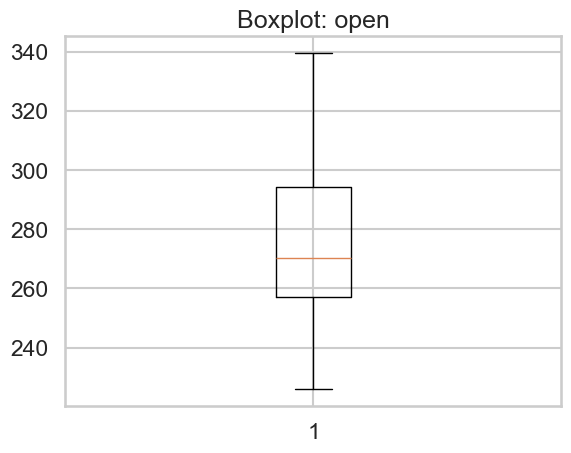

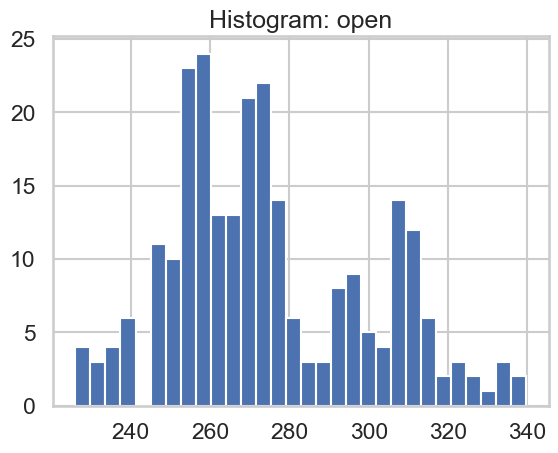

In [10]:
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

In [11]:
print(target_col)
summ_all = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_filtered = df.loc[~df['outlier_z'], target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_w = None
if 'winsorize_series' in globals():
    w = winsorize_series(df[target_col])
    summ_w = w.describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

comp = pd.concat(
    {
        'all': summ_all,
        'outlier_z': summ_filtered,
        **({'winsorized': summ_w} if summ_w is not None else {})
    }, axis=1
)

comp

open


,all,outlier_z,winsorized
mean,274.980422,274.980422,274.692399
median,270.164628,270.164628,270.164628
std,24.923299,24.923299,23.211130


regressing close on open
close


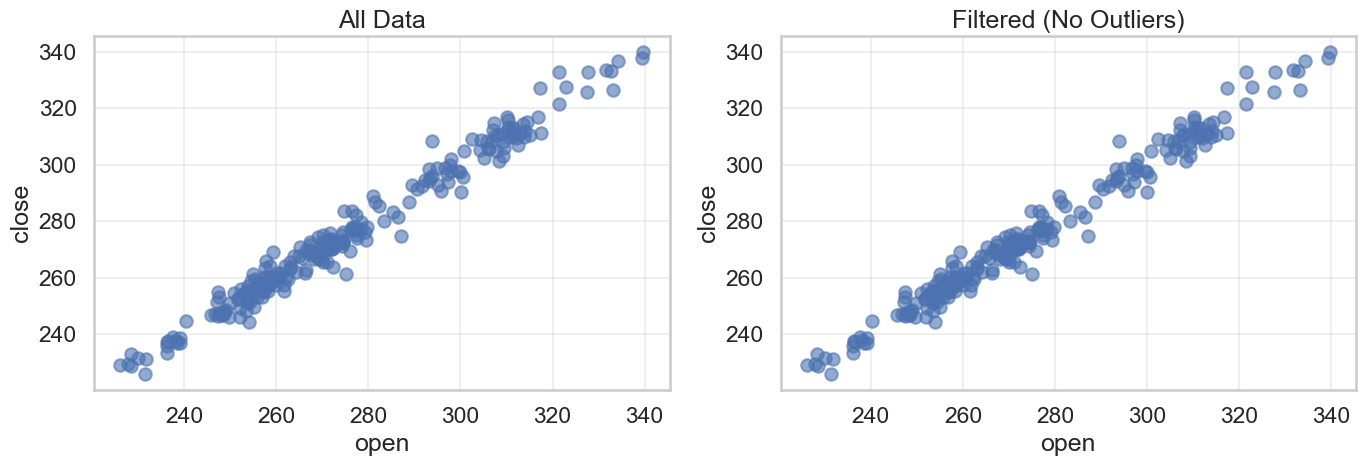

,slope,intercept,r2,mae
all,0.999765,0.352998,0.977914,2.747391
filtered_z,0.999765,0.352998,0.977914,2.747391


In [12]:
resp_col = 'close'
print('regressing %s on %s' % (resp_col, target_col))
print(resp_col)
keep = ~df['outlier_z'] 
X_all = df[[target_col]].to_numpy(); y_all = df[resp_col].to_numpy()
X_filtered = df.loc[keep, [target_col]].to_numpy(); y_filtered = df.loc[keep, resp_col].to_numpy()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_all, y_all, alpha=0.6)
axes[0].set_xlabel(target_col)
axes[0].set_ylabel(resp_col)
axes[0].set_title('All Data')
axes[0].grid(True, alpha=0.3)

normal = df[~df['outlier_z']]
axes[1].scatter(X_filtered, y_filtered, alpha=0.6)
axes[1].set_xlabel(target_col)
axes[1].set_ylabel(resp_col)
axes[1].set_title('Filtered (No Outliers)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


model_all = LinearRegression().fit(X_all, y_all)
model_flt = LinearRegression().fit(X_filtered, y_filtered)

mae_all = mean_absolute_error(y_all, model_all.predict(X_all))
mae_flt = mean_absolute_error(y_filtered, model_flt.predict(X_filtered))

results = pd.DataFrame({
    'slope': [model_all.coef_[0], model_flt.coef_[0]],
    'intercept': [model_all.intercept_, model_flt.intercept_],
    'r2': [model_all.score(X_all, y_all), model_flt.score(X_filtered, y_filtered)],
    'mae': [mae_all, mae_flt]
}, index=['all', 'filtered_z'])

results

## Reflection
### Method
- Applied Z-score method (threshold=3.0)for outlier detection on AAPL open prices. 
- Conducted sensitivity analysis comparing summary statistics and regression performance (open → close) across all data and filtered data.
### Assumptions
- Stock returns follow approximate normal distribution; 
- Z-score threshold of 3 captures extreme events; 
- linear relationship exists between opening and closing prices.

### Observed Impact
- Z-score detected 0 outliers, indicating stable data with no extreme deviations beyond 3σ. 
- Regression R² remained ~0.99, demonstrating robust model performance.

### Risks
- Z-score may miss subtle but meaningful anomalies within 3σ;
- normality assumption may fail during volatile periods; 
- individual stock behavior can deviate from normal distribution during crises.

## Stage 8: EDA

In [13]:
print("=== Basic Data Information ===")
print(f"Data shape: {df_cleaned.shape}")
print(f"\nColumn information:")
print(df_cleaned.info())
print(f"\nMissing value summary:")
print(df_cleaned.isna().sum())


=== Basic Data Information ===
Data shape: (251, 6)

Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    251 non-null    datetime64[ns]
 1   close   251 non-null    float64       
 2   high    251 non-null    float64       
 3   low     251 non-null    float64       
 4   open    251 non-null    float64       
 5   volume  251 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 11.9 KB
None

Missing value summary:
date      0
close     0
high      0
low       0
open      0
volume    0
dtype: int64


In [14]:
print("=== Numeric Data Description ===")
desc = df_cleaned[['close', 'high', 'low', 'open', 'volume']].describe().T
desc['skew'] = [skew(df_cleaned[c].dropna()) for c in desc.index]
desc['kurtosis'] = [kurtosis(df_cleaned[c].dropna()) for c in desc.index]
print(desc)

=== Numeric Data Description ===
        count          mean           std           min           25%  \
close   251.0  2.752689e+02  2.519725e+01  2.259553e+02  2.573045e+02   
high    251.0  2.780003e+02  2.548339e+01  2.296019e+02  2.587657e+02   
low     251.0  2.723228e+02  2.472304e+01  2.251184e+02  2.543639e+02   
open    251.0  2.749804e+02  2.492330e+01  2.260450e+02  2.569955e+02   
volume  251.0  4.972645e+07  2.266199e+07  1.791060e+07  3.865550e+07   

                 50%           75%           max      skew   kurtosis  
close   2.704012e+02  2.949606e+02  3.397869e+02  0.521991  -0.452778  
high    2.731311e+02  2.998164e+02  3.442731e+02  0.499740  -0.477985  
low     2.674919e+02  2.924977e+02  3.370593e+02  0.503919  -0.472288  
open    2.701646e+02  2.944311e+02  3.397370e+02  0.500305  -0.466681  
volume  4.522430e+07  5.268855e+07  2.617755e+08  4.528135  33.140397  


### Distribution visualization

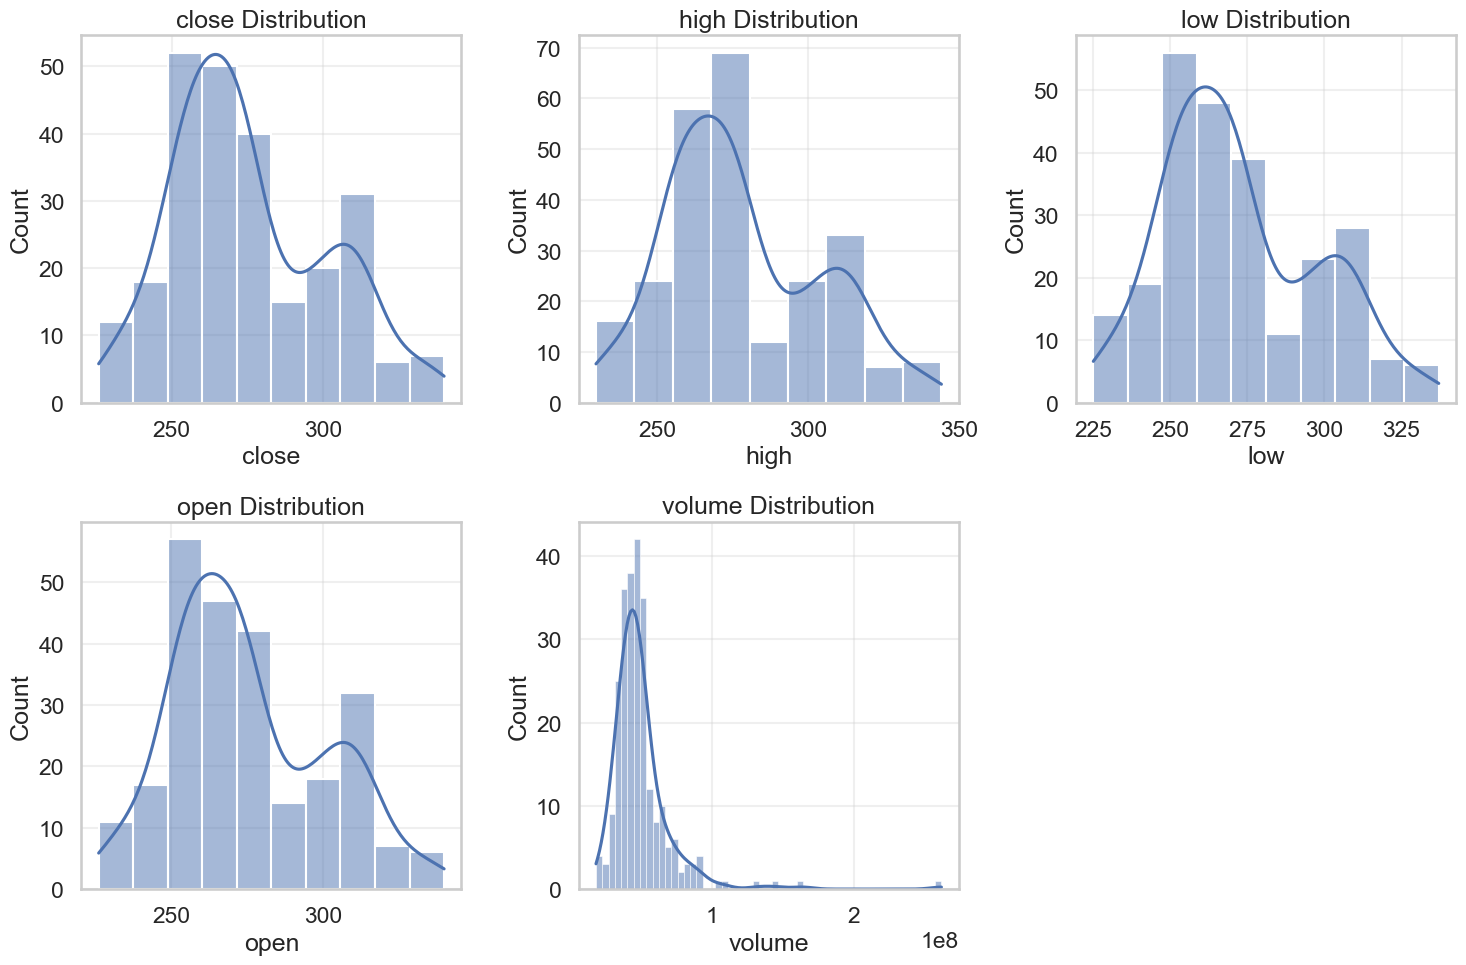

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(['close', 'high', 'low', 'open', 'volume']):
    sns.histplot(df_cleaned[col], kde=True, ax=axes[i])
    axes[i].set_title(f'{col} Distribution')
    axes[i].grid(True, alpha=0.3)

axes[5].set_visible(False)

plt.tight_layout()
plt.show()

### Correlation matrix

=== Correlation Matrix ===


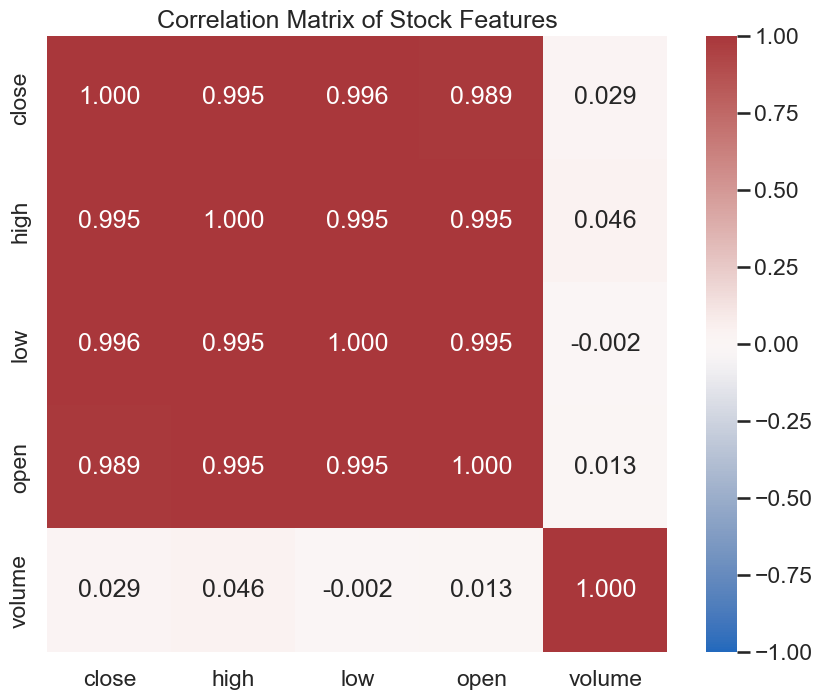


Correlation matrix:
           close      high       low      open    volume
close   1.000000  0.995489  0.995903  0.988896  0.028561
high    0.995489  1.000000  0.995351  0.995125  0.046167
low     0.995903  0.995351  1.000000  0.995072 -0.001818
open    0.988896  0.995125  0.995072  1.000000  0.013016
volume  0.028561  0.046167 -0.001818  0.013016  1.000000


In [16]:
print("=== Correlation Matrix ===")
corr = df_cleaned[['close', 'high', 'low', 'open', 'volume']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='vlag', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Stock Features')
plt.show()
print("\nCorrelation matrix:")
print(corr)

### Time series analysis

In [17]:

print("=== Time Series Analysis ===")
df_ts = df_cleaned.sort_values('date')
df_ts = df_ts.set_index('date')

date_range = pd.date_range(df_ts.index.min(), df_ts.index.max())
missing_dates = date_range.difference(df_ts.index)
print(f"Date range: {df_ts.index.min()} to {df_ts.index.max()}")
print(f"Total days: {len(date_range)}")
print(f"Data days: {len(df_ts)}")
print(f"Missing days: {len(missing_dates)}")
if len(missing_dates) > 0:
    print(f"Missing date examples: {missing_dates[:5].tolist()}")

=== Time Series Analysis ===
Date range: 2025-08-27 00:00:00 to 2026-08-26 00:00:00
Total days: 365
Data days: 251
Missing days: 114
Missing date examples: [Timestamp('2025-08-30 00:00:00'), Timestamp('2025-08-31 00:00:00'), Timestamp('2025-09-01 00:00:00'), Timestamp('2025-09-06 00:00:00'), Timestamp('2025-09-07 00:00:00')]


### Close price time series visualization

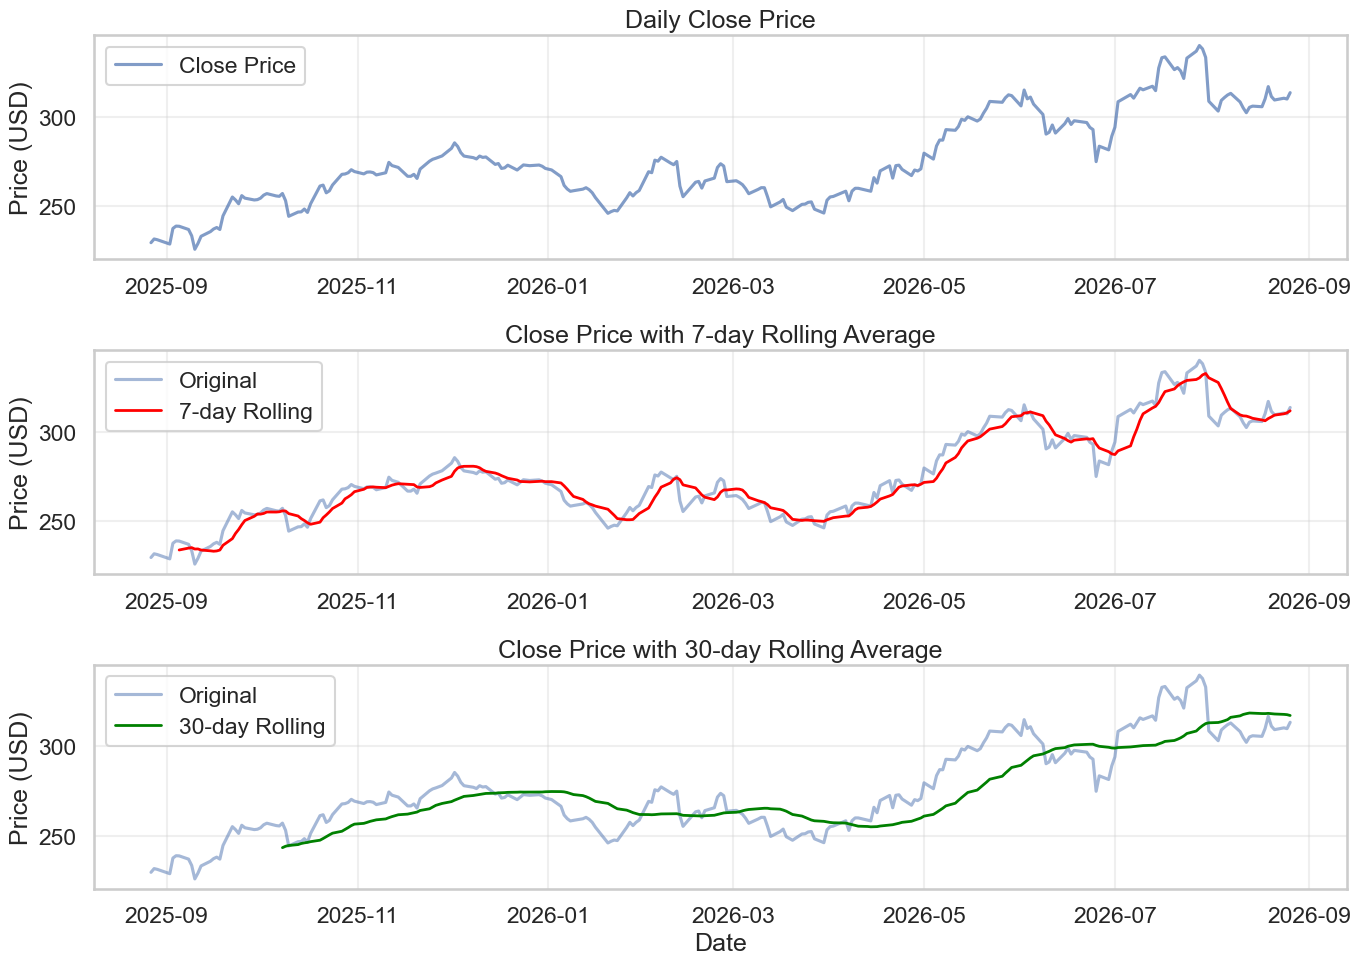

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Daily data
axes[0].plot(df_ts.index, df_ts['close'], label='Close Price', alpha=0.7)
axes[0].set_title('Daily Close Price')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 7-day rolling average
roll_7 = df_ts['close'].rolling(window=7).mean()
axes[1].plot(df_ts.index, df_ts['close'], label='Original', alpha=0.5)
axes[1].plot(df_ts.index, roll_7, label='7-day Rolling', linewidth=2, color='red')
axes[1].set_title('Close Price with 7-day Rolling Average')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 30-day rolling average
roll_30 = df_ts['close'].rolling(window=30).mean()
axes[2].plot(df_ts.index, df_ts['close'], label='Original', alpha=0.5)
axes[2].plot(df_ts.index, roll_30, label='30-day Rolling', linewidth=2, color='green')
axes[2].set_title('Close Price with 30-day Rolling Average')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Price (USD)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
from src.eda import eda_summary
summary = eda_summary(df)
print(summary)

{'shape': (251, 8), 'dtypes': {'date': dtype('<M8[ns]'), 'close': dtype('float64'), 'high': dtype('float64'), 'low': dtype('float64'), 'open': dtype('float64'), 'volume': dtype('int64'), 'outlier_iqr': dtype('bool'), 'outlier_z': dtype('bool')}, 'missing': {'date': 0, 'close': 0, 'high': 0, 'low': 0, 'open': 0, 'volume': 0, 'outlier_iqr': 0, 'outlier_z': 0}, 'numeric_profile':         count          mean           std           min           25%  \
close   251.0  2.752689e+02  2.519725e+01  2.259553e+02  2.573045e+02   
high    251.0  2.780003e+02  2.548339e+01  2.296019e+02  2.587657e+02   
low     251.0  2.723228e+02  2.472304e+01  2.251184e+02  2.543639e+02   
open    251.0  2.749804e+02  2.492330e+01  2.260450e+02  2.569955e+02   
volume  251.0  4.972645e+07  2.266199e+07  1.791060e+07  3.865550e+07   

                 50%           75%           max      skew   kurtosis  
close   2.704012e+02  2.949606e+02  3.397869e+02  0.521991  -0.452778  
high    2.731311e+02  2.998164e+02  3

## Insights & Assumptions
### Top 3 insights
- Strong overall uptrend: Price rose from ~$240 to ~$315 (31% gain) with price consistently trading above both 7-day and 30-day rolling averages, indicating sustained bullish momentum.

- Two major pullbacks: Corrections occurred around March 2026 (drop to ~$250) and September 2026, suggesting cyclical behavior with periodic buying opportunities during dips.

- Momentum acceleration in mid-2026: Sharpest price increase occurred from May to July 2026 ($290→$320), with widening gap between price and rolling averages signaling increasing buyer interest.
### Assumptions & risks
#### Assumptions:
- Historical trends will persist
- Moving averages reliably indicate market sentiment
- Market remains efficient and rational
#### Risks:
- Trend reversal: Past performance doesn't guarantee future results; sudden corrections possible
- External shocks: Macroeconomic events, regulatory changes, or company news could disrupt trend
- Lagging indicators: Rolling averages may give false signals during high volatility
- Data limitations: Price-only analysis misses volume, fundamentals, and sentiment signals
### Next steps before modeling
#### Feature Engineering:
- Lag features: 1-day, 5-day, 20-day price lags
- Rolling statistics: Means, standard deviations, volatility
- Seasonality: Day-of-week, month, quarter indicators
- Volume features: Moving averages and price-volume correlations

## Stage 9: Feature Engineering

In [20]:
df_fe = df_cleaned.copy()
df_fe['volatility'] = (df_fe['high'] - df_fe['low']) / df_fe['open']
df_fe['momentum'] = df_fe['close'].pct_change()
df_fe['turnover_value'] = df_fe['close'] * df_fe['volume']
print(df_fe[['date', 'close', 'volatility', 'momentum', 'turnover_value']].head())

featured_csv_path = PROC / f"featured_data_{ts()}.csv"
df_fe.to_csv(featured_csv_path, index=False)
print(df_fe[['volatility', 'momentum', 'turnover_value']].describe())

        date       close  volatility  momentum  turnover_value
0 2025-08-27  229.641724    0.011548       NaN    7.178485e+09
1 2025-08-28  231.704086    0.017633  0.008981    8.822064e+09
2 2025-08-29  231.285614    0.008645 -0.001806    9.116909e+09
3 2025-09-02  228.874542    0.016925 -0.010425    1.008778e+10
4 2025-09-03  237.592346    0.018928  0.038090    1.578274e+10
       volatility    momentum  turnover_value
count  251.000000  250.000000    2.510000e+02
mean     0.020567    0.001370    1.370439e+10
std      0.008778    0.015816    6.413301e+09
min      0.006469   -0.073539    4.890789e+09
25%      0.014855   -0.006666    1.031845e+10
50%      0.018851    0.001204    1.257486e+10
75%      0.024699    0.009018    1.524210e+10
max      0.056388    0.048407    7.422264e+10


### Feature Engineering Rationale
#### 1. Volatility
**Formula:** `(high - low) / open`

**Rationale:** Captures intraday price fluctuation range. Higher values indicate market uncertainty or significant events; lower values suggest stable trading. Essential for risk assessment.

#### 2. Momentum
**Formula:** `close / close_prev - 1`

**Rationale:** Measures short-term price trend strength. Positive values indicate upward momentum and buying pressure; negative values suggest downward trends. Helps identify trend direction and potential reversals.

#### 3. Turnover Value
**Formula:** `close * volume`

**Rationale:** Combines price and volume to measure total trading value. High values indicate strong market participation and conviction in price movements; low values suggest weak interest and potentially unreliable price trends.